# Predicting Diabetes Using Machine Learning

This notebook builds a reproducible diabetes prediction workflow using a Kaggle healthcare diabetes dataset. It inspects the data, visualizes feature relationships, trains classification models, and compares model performance.

## Context & Methods

Dataset source: https://www.kaggle.com/datasets/ehababoelnaga/diabetes-dataset

The target variable is `Outcome`, where `1` indicates diabetes and `0` indicates no diabetes. The workflow uses an 80/20 stratified train-test split with `random_state=100` for reproducibility.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve

sns.set_theme(style="whitegrid")

mkdir -p failed for path C:\Users\walte\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\walte\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\walte\AppData\Local\Temp\matplotlib-2iadk6v4 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Dataset

In [2]:
file_path = "Healthcare-Diabetes.csv"
df = pd.read_csv(file_path)
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


## Data Inspection

In [3]:
print("Dataset shape:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["Outcome"].value_counts())

Dataset shape:
(2768, 10)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB
None

Missing values:
Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
Sk

## Descriptive Statistics

In [4]:
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


## Correlation Heatmap

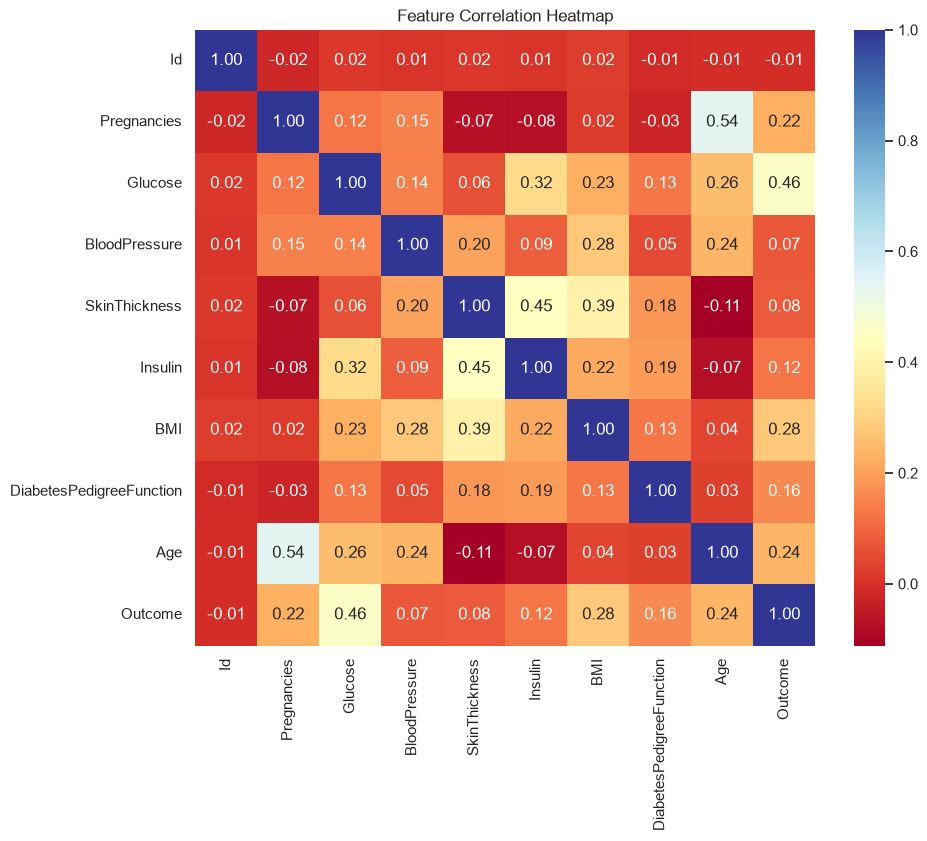

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="RdYlBu", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Split Features And Target

The `Id` column is a row identifier, not a clinical feature, so it is removed before model training.

In [6]:
feature_df = df.drop(columns=["Outcome", "Id"], errors="ignore")
target = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    target,
    test_size=0.2,
    random_state=100,
    stratify=target
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2214, 8)
X_test: (554, 8)
y_train: (2214,)
y_test: (554,)


## Random Forest Model

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=100
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

## Random Forest Evaluation

In [8]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_probabilities = random_forest.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1 Score:", round(rf_f1, 3))
print("ROC-AUC:", round(rf_roc_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results
Accuracy: 0.987
Precision: 0.989
Recall: 0.974
F1 Score: 0.982
ROC-AUC: 0.996

Confusion Matrix:
[[361   2]
 [  5 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       363
           1       0.99      0.97      0.98       191

    accuracy                           0.99       554
   macro avg       0.99      0.98      0.99       554
weighted avg       0.99      0.99      0.99       554



## Feature Importance

                    Feature  Importance
1                   Glucose    0.260579
5                       BMI    0.171222
7                       Age    0.138887
6  DiabetesPedigreeFunction    0.123509
2             BloodPressure    0.085987
0               Pregnancies    0.079010
4                   Insulin    0.073305
3             SkinThickness    0.067499


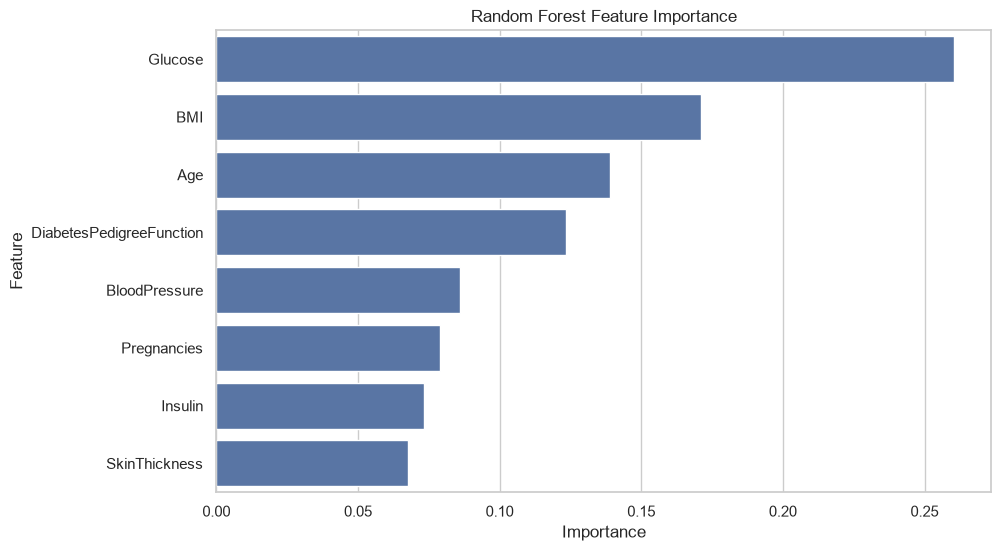

In [9]:
feature_importance = pd.DataFrame({
    "Feature": feature_df.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

## Cleaned Dataset

Some clinical measurements cannot realistically be zero. Those values are treated as missing. Model pipelines will learn median imputation values from the training data only, which avoids test-data leakage.

In [10]:
zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = (df[zero_as_missing_columns] == 0).sum().sort_values(ascending=False)
print("Zero values treated as missing:")
print(zero_counts)

cleaned_df = df.drop(columns=["Id"], errors="ignore").copy()
cleaned_df[zero_as_missing_columns] = cleaned_df[zero_as_missing_columns].replace(0, np.nan)

print("\nMissing values after zero replacement:")
print(cleaned_df.isnull().sum())

cleaned_df.head()

Zero values treated as missing:
Insulin          1330
SkinThickness     800
BloodPressure     125
BMI                39
Glucose            18
dtype: int64

Missing values after zero replacement:
Pregnancies                    0
Glucose                       18
BloodPressure                125
SkinThickness                800
Insulin                     1330
BMI                           39
DiabetesPedigreeFunction       0
Age                            0
Outcome                        0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Random Forest Pipeline Using Cleaned Dataset

This pipeline imputes missing values with training-set medians before fitting the Random Forest model.

In [11]:
X_clean = cleaned_df.drop("Outcome", axis=1)
y_clean = cleaned_df["Outcome"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=100,
    stratify=y_clean
)

clean_random_forest = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=100
    ))
])

clean_random_forest.fit(X_train_clean, y_train_clean)
clean_rf_predictions = clean_random_forest.predict(X_test_clean)

clean_rf_accuracy = accuracy_score(y_test_clean, clean_rf_predictions)
clean_rf_precision = precision_score(y_test_clean, clean_rf_predictions)
clean_rf_recall = recall_score(y_test_clean, clean_rf_predictions)
clean_rf_f1 = f1_score(y_test_clean, clean_rf_predictions)
clean_rf_probabilities = clean_random_forest.predict_proba(X_test_clean)[:, 1]
clean_rf_roc_auc = roc_auc_score(y_test_clean, clean_rf_probabilities)

print("Cleaned Random Forest Pipeline Results")
print("Accuracy:", round(clean_rf_accuracy, 3))
print("Precision:", round(clean_rf_precision, 3))
print("Recall:", round(clean_rf_recall, 3))
print("F1 Score:", round(clean_rf_f1, 3))
print("ROC-AUC:", round(clean_rf_roc_auc, 3))

Cleaned Random Forest Pipeline Results
Accuracy: 0.989
Precision: 0.995
Recall: 0.974
F1 Score: 0.984
ROC-AUC: 0.997


## Logistic Regression Pipeline

This pipeline imputes missing values, scales numeric features, and then fits Logistic Regression.

In [12]:
logistic_regression = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=100,
        max_iter=1000
    ))
])

logistic_regression.fit(X_train_clean, y_train_clean)
log_predictions = logistic_regression.predict(X_test_clean)

log_accuracy = accuracy_score(y_test_clean, log_predictions)
log_precision = precision_score(y_test_clean, log_predictions)
log_recall = recall_score(y_test_clean, log_predictions)
log_f1 = f1_score(y_test_clean, log_predictions)
log_probabilities = logistic_regression.predict_proba(X_test_clean)[:, 1]
log_roc_auc = roc_auc_score(y_test_clean, log_probabilities)

print("Logistic Regression Pipeline Results")
print("Accuracy:", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1 Score:", round(log_f1, 3))
print("ROC-AUC:", round(log_roc_auc, 3))

Logistic Regression Pipeline Results
Accuracy: 0.751
Precision: 0.669
Recall: 0.55
F1 Score: 0.603
ROC-AUC: 0.822


## Cross-Validation

Cross-validation evaluates model stability across multiple stratified train/test folds instead of relying only on one split.

In [13]:
cross_validator = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models_for_cv = {
    "Cleaned Random Forest Pipeline": clean_random_forest,
    "Logistic Regression Pipeline": logistic_regression
}

cv_summary_rows = []
for model_name, model in models_for_cv.items():
    scores = cross_validate(
        model,
        X_clean,
        y_clean,
        cv=cross_validator,
        scoring=scoring,
        n_jobs=1
    )
    row = {"Model": model_name}
    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = values.mean()
        row[f"{metric_name}_std"] = values.std()
    cv_summary_rows.append(row)

cv_results = pd.DataFrame(cv_summary_rows)
cv_results.round(3)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Cleaned Random Forest Pipeline,0.988,0.004,0.980,0.010,0.984,0.013,0.982,0.007,0.999,0.001
1,Logistic Regression Pipeline,0.773,0.007,0.722,0.024,0.556,0.025,0.627,0.011,0.840,0.007


## Tune Random Forest

Hyperparameter tuning searches for a Random Forest configuration that improves recall while keeping the preprocessing pipeline intact.

In [14]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 4, 6],
    "model__min_samples_leaf": [1, 3, 5]
}

tuned_random_forest = GridSearchCV(
    estimator=clean_random_forest,
    param_grid=param_grid,
    scoring="recall",
    cv=cross_validator,
    n_jobs=1
)

tuned_random_forest.fit(X_train_clean, y_train_clean)

tuned_rf_predictions = tuned_random_forest.predict(X_test_clean)
tuned_rf_probabilities = tuned_random_forest.predict_proba(X_test_clean)[:, 1]

tuned_rf_accuracy = accuracy_score(y_test_clean, tuned_rf_predictions)
tuned_rf_precision = precision_score(y_test_clean, tuned_rf_predictions)
tuned_rf_recall = recall_score(y_test_clean, tuned_rf_predictions)
tuned_rf_f1 = f1_score(y_test_clean, tuned_rf_predictions)
tuned_rf_roc_auc = roc_auc_score(y_test_clean, tuned_rf_probabilities)

print("Best Random Forest Parameters:")
print(tuned_random_forest.best_params_)

print("\nTuned Random Forest Pipeline Results")
print("Accuracy:", round(tuned_rf_accuracy, 3))
print("Precision:", round(tuned_rf_precision, 3))
print("Recall:", round(tuned_rf_recall, 3))
print("F1 Score:", round(tuned_rf_f1, 3))
print("ROC-AUC:", round(tuned_rf_roc_auc, 3))

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Tuned Random Forest Pipeline Results
Accuracy: 0.989
Precision: 0.995
Recall: 0.974
F1 Score: 0.984
ROC-AUC: 0.997


## Permutation Feature Importance

Permutation importance measures how much model performance changes when each feature is shuffled. This is a model-agnostic interpretation method and is more reliable for the pipeline than raw tree importance alone.

                    Feature  Importance Mean  Importance Std
1                   Glucose         0.102042        0.010376
5                       BMI         0.037457        0.003255
7                       Age         0.037308        0.003494
6  DiabetesPedigreeFunction         0.015571        0.001869
4                   Insulin         0.011616        0.001841
0               Pregnancies         0.008748        0.001186
3             SkinThickness         0.007421        0.000847
2             BloodPressure         0.004229        0.001234


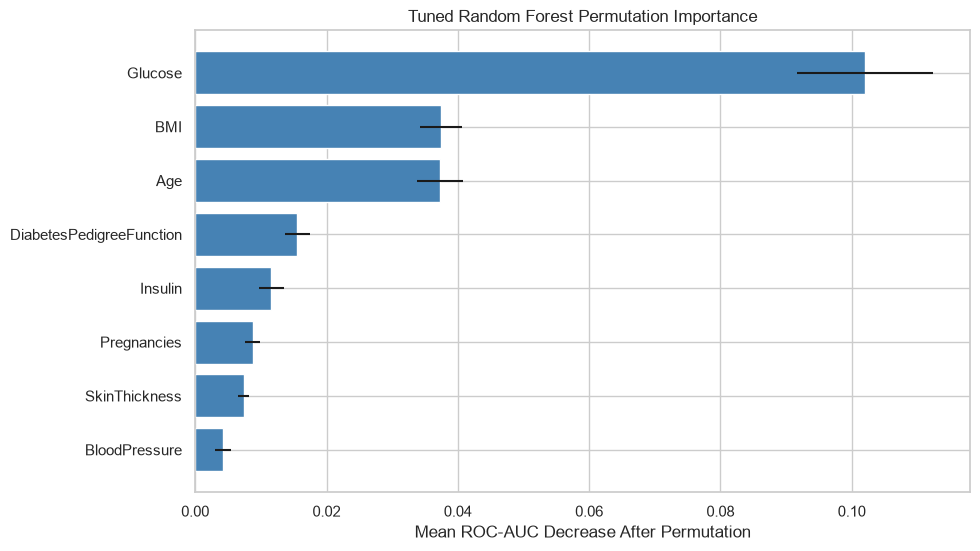

In [15]:
permutation_results = permutation_importance(
    tuned_random_forest.best_estimator_,
    X_test_clean,
    y_test_clean,
    scoring="roc_auc",
    n_repeats=10,
    random_state=100,
    n_jobs=1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance Mean": permutation_results.importances_mean,
    "Importance Std": permutation_results.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print(permutation_importance_df)

plot_data = permutation_importance_df.sort_values(by="Importance Mean", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["Feature"],
    plot_data["Importance Mean"],
    xerr=plot_data["Importance Std"],
    color="steelblue"
)
plt.title("Tuned Random Forest Permutation Importance")
plt.xlabel("Mean ROC-AUC Decrease After Permutation")
plt.show()

## Detailed Evaluation Visuals

These plots show the type of errors each pipeline model makes and how the models trade off recall and precision across thresholds.

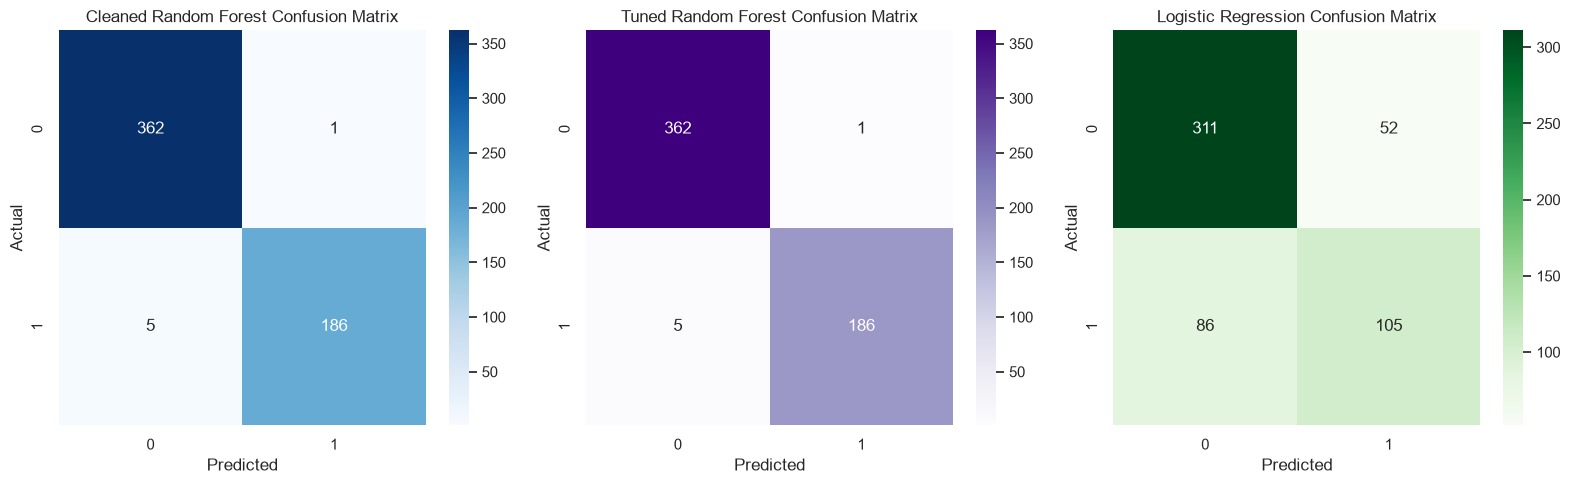

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

confusion_items = [
    ("Cleaned Random Forest", clean_rf_predictions, "Blues"),
    ("Tuned Random Forest", tuned_rf_predictions, "Purples"),
    ("Logistic Regression", log_predictions, "Greens")
]

for axis, (title, predictions, color_map) in zip(axes, confusion_items):
    sns.heatmap(
        confusion_matrix(y_test_clean, predictions),
        annot=True,
        fmt="d",
        cmap=color_map,
        ax=axis
    )
    axis.set_title(f"{title} Confusion Matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

plt.tight_layout()
plt.show()

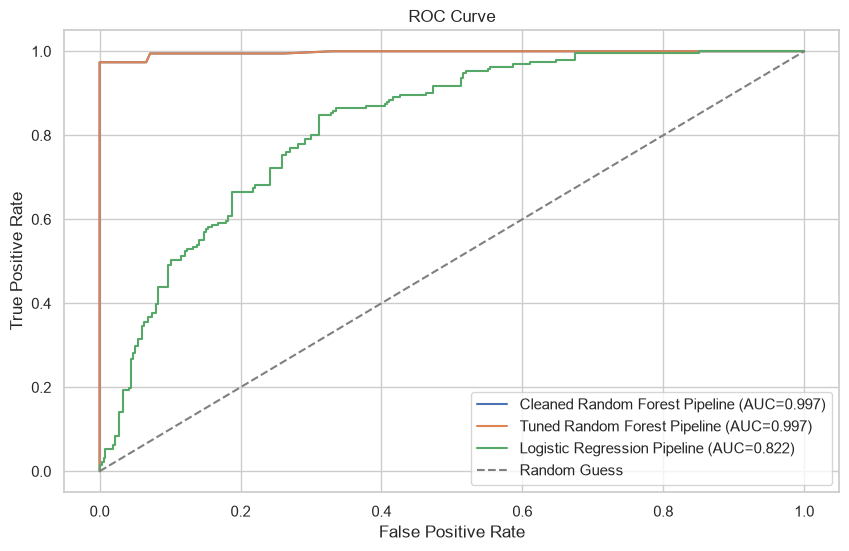

In [17]:
plt.figure(figsize=(10, 6))
for model_name, probabilities in {
    "Cleaned Random Forest Pipeline": clean_rf_probabilities,
    "Tuned Random Forest Pipeline": tuned_rf_probabilities,
    "Logistic Regression Pipeline": log_probabilities
}.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test_clean, probabilities)
    auc_score = roc_auc_score(y_test_clean, probabilities)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

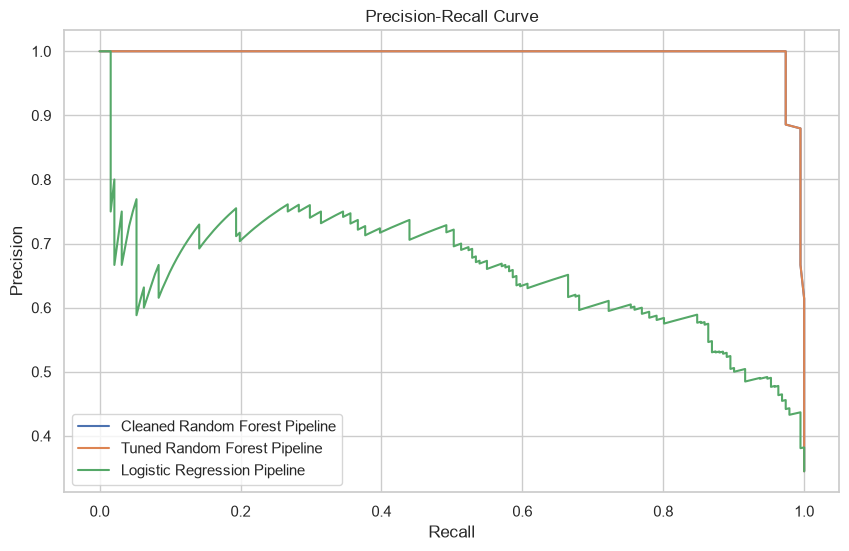

In [18]:
plt.figure(figsize=(10, 6))
for model_name, probabilities in {
    "Cleaned Random Forest Pipeline": clean_rf_probabilities,
    "Tuned Random Forest Pipeline": tuned_rf_probabilities,
    "Logistic Regression Pipeline": log_probabilities
}.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test_clean, probabilities)
    plt.plot(recall_values, precision_values, label=model_name)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## Model Comparison

In [19]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Cleaned Random Forest Pipeline",
        "Tuned Random Forest Pipeline",
        "Logistic Regression Pipeline"
    ],
    "Accuracy": [
        rf_accuracy,
        clean_rf_accuracy,
        tuned_rf_accuracy,
        log_accuracy
    ],
    "Precision": [
        rf_precision,
        clean_rf_precision,
        tuned_rf_precision,
        log_precision
    ],
    "Recall": [
        rf_recall,
        clean_rf_recall,
        tuned_rf_recall,
        log_recall
    ],
    "F1 Score": [
        rf_f1,
        clean_rf_f1,
        tuned_rf_f1,
        log_f1
    ],
    "ROC-AUC": [
        rf_roc_auc,
        clean_rf_roc_auc,
        tuned_rf_roc_auc,
        log_roc_auc
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.987,0.989,0.974,0.982,0.996
1,Cleaned Random Forest Pipeline,0.989,0.995,0.974,0.984,0.997
2,Tuned Random Forest Pipeline,0.989,0.995,0.974,0.984,0.997
3,Logistic Regression Pipeline,0.751,0.669,0.550,0.603,0.822


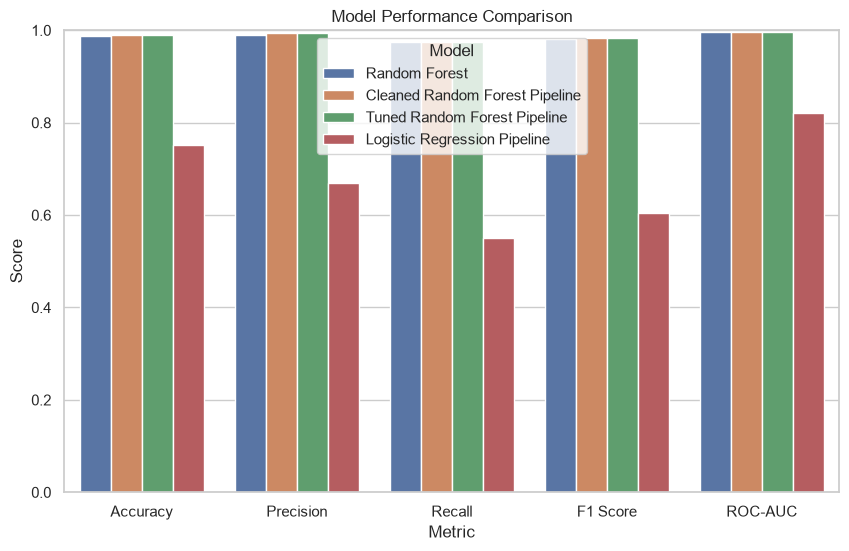

In [20]:
plt.figure(figsize=(10, 6))
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.show()

## Takeaways

The final comparison table should be used to choose the strongest model for the project goal. For diabetes screening, recall is especially important because false negatives can miss patients who may need follow-up. This project is educational and should not be used for medical diagnosis.